# Function 3

The function is described by 3 input features, each of which is normalised to lie within the range 0 to 1. The optimisation goal is to maximise the output value. The function describes the side-effects from a combination of three compounds din a drug-discovery project. The side-effects have been converted to negative values, and therefore the larger the output, the lower the impact from side-effects. The initial data set consists of 15 data points.

## Week 1 - Initial exploration

In [1]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF

from bbo.data import get_current_weeks_points
from bbo.plotting import plot_2d_array
from bbo.random import create_rng_seed
from bbo.utils import construct_meshgrid

seed_input = "function 3"  # input string to create random seed
n_dimensions = 3  # number of features
grd_res = 101  # axis resolution

In [2]:
X, y = get_current_weeks_points(function_id=3, week=1)

print(f"Mean = {y.mean()}")
print(f"Standard deviation = {y.std()}")

print(f"Minimum = {y.min()}")
quantiles = [0.25, 0.5, 0.75]
for quantile in quantiles:
    print(f"{quantile * 100}% quantile = {np.quantile(y, quantile)}")
print(f"Maximum = {y.max()}")

Mean = -0.10716697472812112
Standard deviation = 0.08421399358525467
Minimum = -0.3989255131463011
25.0% quantile = -0.11299535762560445
50.0% quantile = -0.10596503573558178
75.0% quantile = -0.052382977973079024
Maximum = -0.034835313350078584


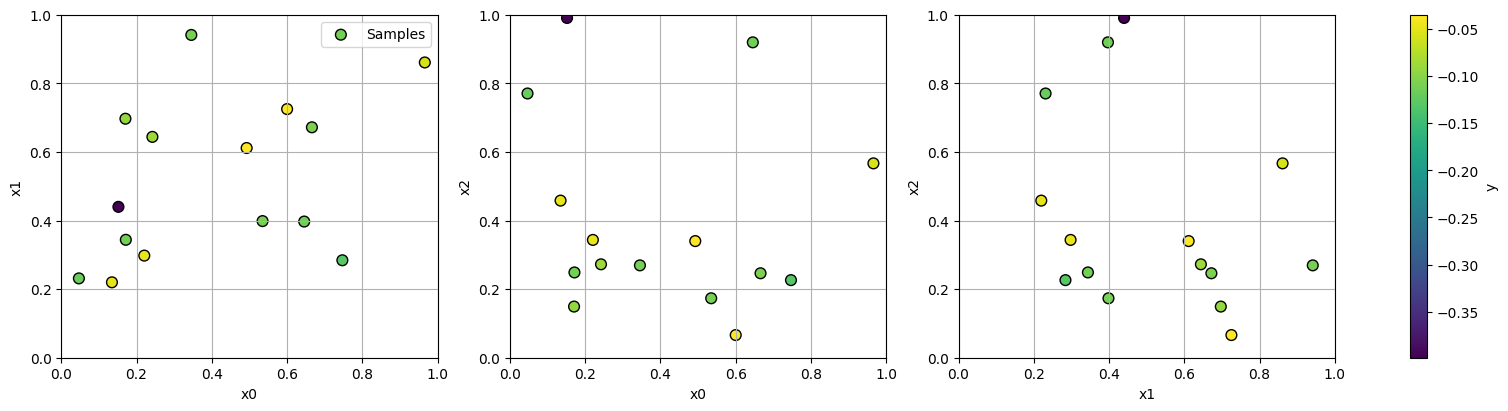

In [3]:
fig, axs = plot_2d_array(X, y)

In [4]:
# Fit Gaussian Process surrogate model on known data
kernel = RBF(length_scale=[0.1, 0.1, 0.1], length_scale_bounds='fixed')
model = GaussianProcessRegressor(
    kernel=kernel, n_restarts_optimizer=10, normalize_y=True, random_state=create_rng_seed(seed_input)
)
model.fit(X, y)

# Perform grid search to evaluate model output
X_grid = construct_meshgrid(n_dimensions=n_dimensions, grd_res=grd_res)
X_pred = np.column_stack([x_grid.ravel() for x_grid in X_grid])
y_mean, y_std = model.predict(X_pred, return_std=True)

# Use standard deviation as acquisition function for pure exploration
max_idx = np.argsort(y_std)[:-6:-1]
x_candidates = X_pred[max_idx]
print("Proposed points using pure exploration acquisition function:")
for candidate in x_candidates:
    print(candidate)

Proposed points using pure exploration acquisition function:
[0.52 0.99 0.97]
[0.52 0.99 0.98]
[0.   0.99 0.78]
[0.   0.99 0.77]
[0.45 1.   1.  ]


The top 5 candidates are shown above. When conducting this analysis before submitting my query, I did not set the `random_state` when creating the Gaussian Process surrogate model. Therefore, the optimiser used a different set of random starting points during each iteration. As a result, the acquisition function suggested a different point of (0.43, 0.97, 0.88), which was submitted in this week's query. As the `random_state` is unknown, this cannot be reproduced here. However, it is not too far from the top proposed point given above, and because we have very few data points to work with, discrepancies like this are expected.

## Week 2

In [5]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF

from bbo import acquisition
from bbo.data import get_current_weeks_points
from bbo.plotting import plot_2d_array
from bbo.random import create_rng_seed
from bbo.utils import construct_meshgrid

seed_input = "function 3"  # input string to create random seed
n_dimensions = 3  # number of features
grd_res = 101  # axis resolution

In [6]:
X, y = get_current_weeks_points(function_id=3, week=2)

print(f"Last week's query {X[-1]} yields {y[-1]}")

Last week's query [0.43 0.97 0.88] yields -0.07137836141668699


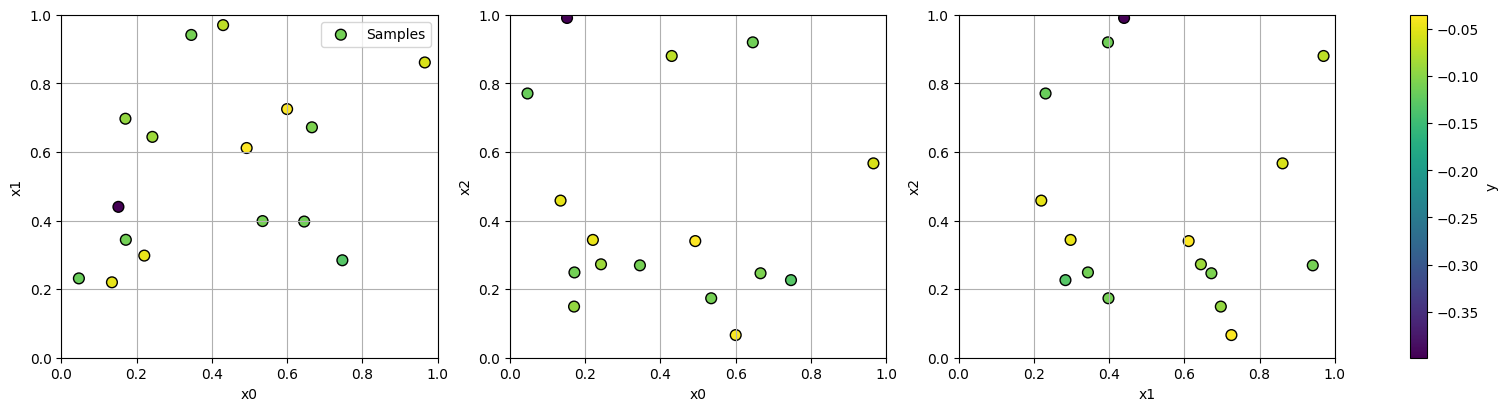

In [7]:
fig, axs = plot_2d_array(X, y)

In [8]:
# Fit Gaussian Process surrogate model on known data
kernel = RBF(length_scale=[0.1, 0.1, 0.1], length_scale_bounds='fixed')
model = GaussianProcessRegressor(
    kernel=kernel, n_restarts_optimizer=10, normalize_y=True, random_state=create_rng_seed(seed_input)
)
model.fit(X, y)

# Perform grid search to evaluate model output
X_grid = construct_meshgrid(n_dimensions=n_dimensions, grd_res=grd_res)
X_pred = np.column_stack([x_grid.ravel() for x_grid in X_grid])
y_mean, y_std = model.predict(X_pred, return_std=True)

# Use Upper Confidence Bound (UCB) acquisition function with k = 1.96 (95% confidence interval)
max_idx = np.argmax(acquisition.ucb(y_mean, y_std, k=1.96))
x_next = X_pred[max_idx]
print(f"Proposed point using Upper Confidence Bound (k = 1.96) acquisition function = {x_next}")

Proposed point using Upper Confidence Bound (k = 1.96) acquisition function = [0.48 0.67 0.18]


## Week 3

In [9]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF

from bbo import acquisition
from bbo.data import get_current_weeks_points
from bbo.plotting import plot_2d_array
from bbo.random import create_rng_seed
from bbo.utils import construct_meshgrid

seed_input = "function 3"  # input string to create random seed
n_dimensions = 3  # number of features
grd_res = 101  # axis resolution

In [10]:
X, y = get_current_weeks_points(function_id=3, week=3)

print(f"Last week's query {X[-1]} yields {y[-1]}")

Last week's query [0.48 0.67 0.18] yields -0.1169364000797603


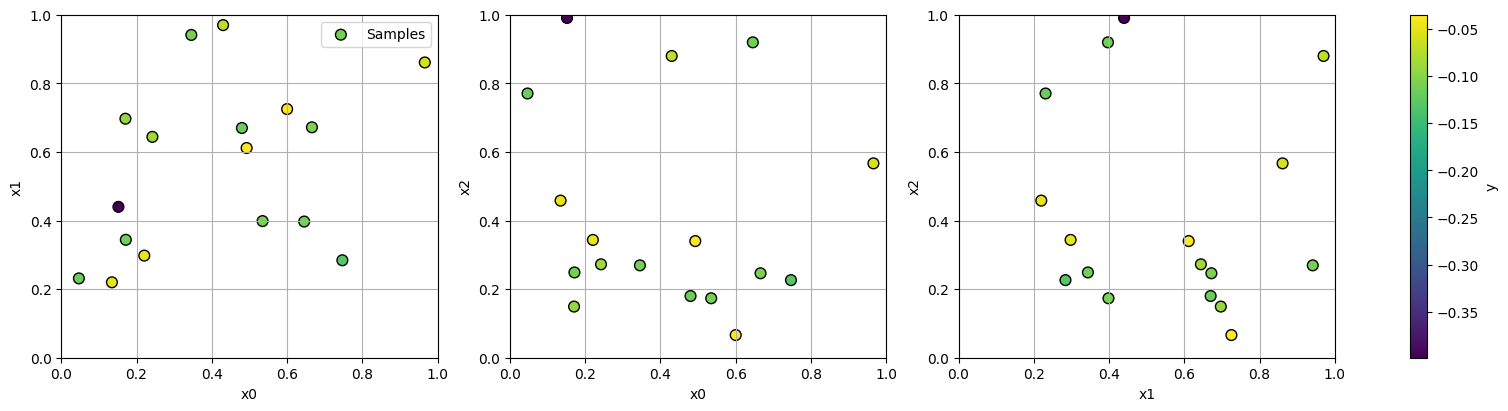

In [11]:
fig, axs = plot_2d_array(X, y)

In [12]:
# Fit Gaussian Process surrogate model on known data
kernel = RBF(length_scale=[0.1, 0.1, 0.1], length_scale_bounds='fixed')
model = GaussianProcessRegressor(
    kernel=kernel, n_restarts_optimizer=10, normalize_y=True, random_state=create_rng_seed(seed_input)
)
model.fit(X, y)

# Perform grid search to evaluate model output
X_grid = construct_meshgrid(n_dimensions=n_dimensions, grd_res=grd_res)
X_pred = np.column_stack([x_grid.ravel() for x_grid in X_grid])
y_mean, y_std = model.predict(X_pred, return_std=True)

# Use Upper Confidence Bound (UCB) acquisition function with k = 1.96 (95% confidence interval)
max_idx = np.argmax(acquisition.ucb(y_mean, y_std, k=1.96))
x_next = X_pred[max_idx]
print(f"Proposed point using Upper Confidence Bound (k = 1.96) acquisition function = {x_next}")

Proposed point using Upper Confidence Bound (k = 1.96) acquisition function = [0.28 0.24 0.46]


## Week 4

In [13]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF

from bbo import acquisition
from bbo.data import get_current_weeks_points
from bbo.plotting import plot_2d_array
from bbo.random import create_rng_seed
from bbo.utils import grid_search

seed_input = "function 3"  # input string to create random seed
n_dimensions = 3  # number of features
grd_res = 101  # axis resolution

In [14]:
X, y = get_current_weeks_points(function_id=3, week=4)

print(f"Last week's query {X[-1]} yields {y[-1]}")

Last week's query [0.282  0.243  0.4602] yields -0.03465873293384881


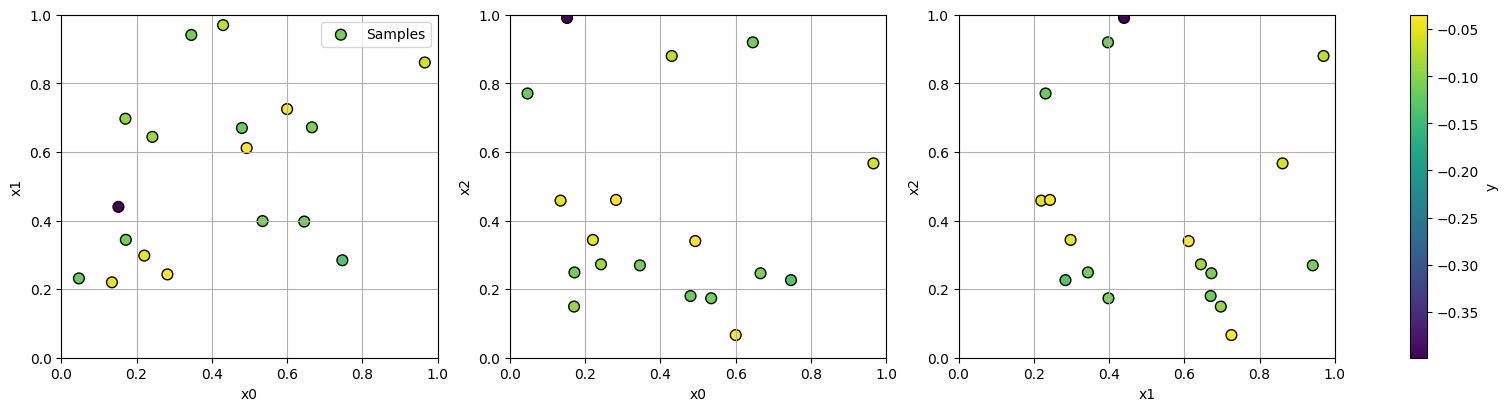

In [15]:
fig, axs = plot_2d_array(X, y)

In [16]:
# Fit Gaussian Process surrogate model on known data
kernel = RBF(length_scale=[0.1, 0.1, 0.1], length_scale_bounds='fixed')
model = GaussianProcessRegressor(
    kernel=kernel, n_restarts_optimizer=10, normalize_y=True, random_state=create_rng_seed(seed_input)
)
model.fit(X, y)

# Use Upper Confidence Bound (UCB) acquisition function with k = 1.96 (95% confidence interval)
x_next = grid_search(model, acq_func=acquisition.ucb, k=1.96, n_dimensions=3, grd_res=grd_res)
print(f"Proposed point using Upper Confidence Bound (k = 1.96) acquisition function = {x_next}")

Proposed point using Upper Confidence Bound (k = 1.96) acquisition function = [0.23933169 0.14933169 0.36933169]


## Week 5

In [17]:
import numpy as np

from bbo import acquisition
from bbo.bayesian_optimisation import get_reg_model
from bbo.data import get_current_weeks_points
from bbo.plotting import plot_2d_array
from bbo.random import create_rng_seed
from bbo.utils import grid_search

seed_input = "function 3"  # input string to create random seed
n_dimensions = 3  # number of features
grd_res = 101  # axis resolution

In [18]:
X, y = get_current_weeks_points(function_id=3, week=5)

print(f"Last week's query {X[-1]} yields {y[-1]}")

Last week's query [0.237909 0.153941 0.364976] yields -0.06696252385033168


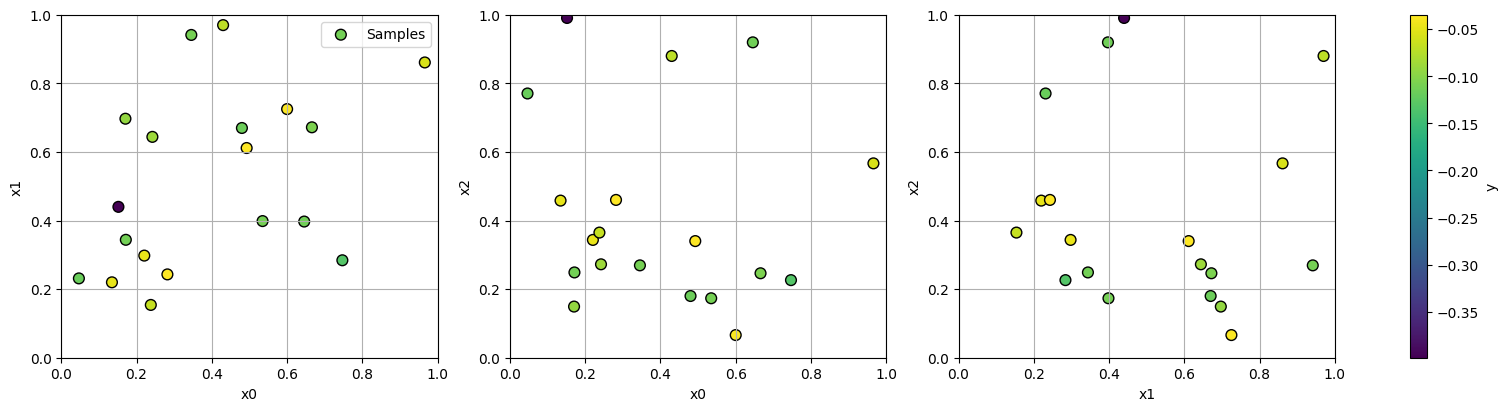

In [19]:
fig, axs = plot_2d_array(X, y)

In [20]:
# Fit Gaussian Process surrogate model on known data
model = get_reg_model(
    n_dimensions=3, seed_input=seed_input, length_scale_bounds=(1e-2, 10)
)
model.fit(X, y)

# Use Upper Confidence Bound (UCB) acquisition function with k = 1.96 (95% confidence interval)
x_next = grid_search(
    model,
    acq_func=acquisition.ucb,
    k=1.96,
    n_dimensions=3,
    grd_res=grd_res,
    bounds=[(0.02, 0.98) for _ in range(n_dimensions)]
)
print(f"Proposed point using Upper Confidence Bound (k = 1.96) acquisition function = {x_next}")

Proposed point using Upper Confidence Bound (k = 1.96) acquisition function = [0.98    0.98    0.47552]


## Week 6

In [21]:
import numpy as np

from bbo import acquisition
from bbo.bayesian_optimisation import get_reg_model
from bbo.data import get_current_weeks_points
from bbo.plotting import plot_2d_array
from bbo.random import create_rng_seed
from bbo.utils import grid_search

seed_input = "function 3"  # input string to create random seed
n_dimensions = 3  # number of features
grd_res = 101  # axis resolution

In [22]:
X, y = get_current_weeks_points(function_id=3, week=6)

print(f"Last week's query {X[-1]} yields {y[-1]}")

Last week's query [0.980204 0.980204 0.475469] yields -0.042247037731646765


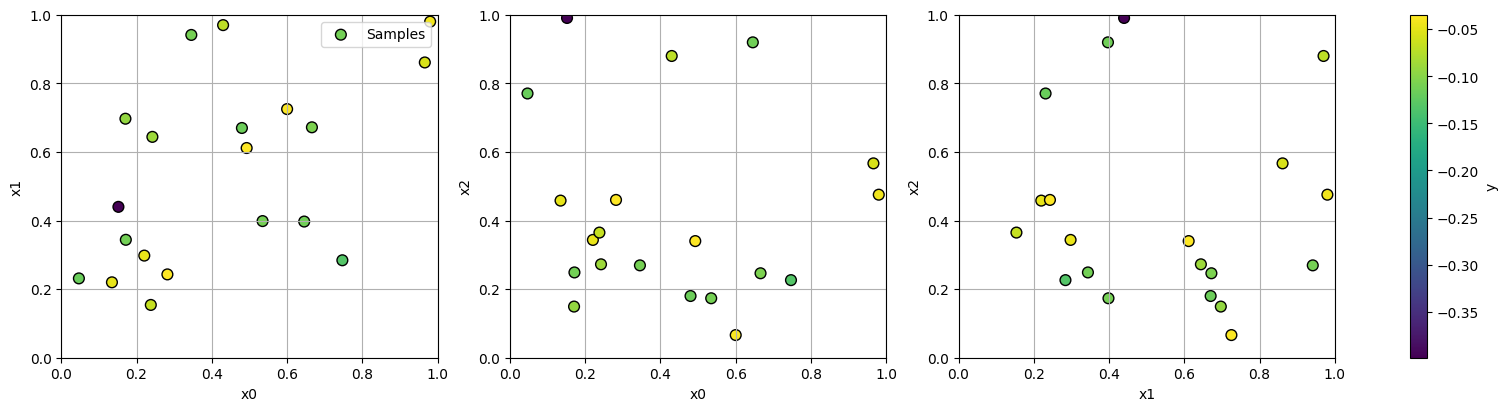

In [23]:
fig, axs = plot_2d_array(X, y)

In [24]:
# Fit Gaussian Process surrogate model on known data
model = get_reg_model(
    n_dimensions=3, seed_input=seed_input, length_scale_bounds=(1e-2, 10)
)
model.fit(X, y)

# Use Upper Confidence Bound (UCB) acquisition function with k = 1.96 (95% confidence interval)
x_next = grid_search(
    model,
    acq_func=acquisition.ucb,
    k=1.96,
    n_dimensions=3,
    grd_res=grd_res,
    bounds=[(0.02, 0.98) for _ in range(n_dimensions)]
)
print(f"Proposed point using Upper Confidence Bound (k = 1.96) acquisition function = {x_next}")

Proposed point using Upper Confidence Bound (k = 1.96) acquisition function = [0.98       0.02337248 0.51297248]


## Week 7

In [25]:
import numpy as np

from bbo import acquisition
from bbo.bayesian_optimisation import get_reg_model
from bbo.data import get_current_weeks_points
from bbo.plotting import plot_2d_array
from bbo.random import create_rng_seed
from bbo.utils import suggest_local_candidates

seed_input = "function 3"  # input string to create random seed
n_dimensions = 3  # number of features
grd_res = 101  # axis resolution

In [26]:
X, y = get_current_weeks_points(function_id=3, week=7)

print(f"Last week's query {X[-1]} yields {y[-1]}")

Last week's query [0.980204 0.019796 0.513782] yields -0.08303330261304989


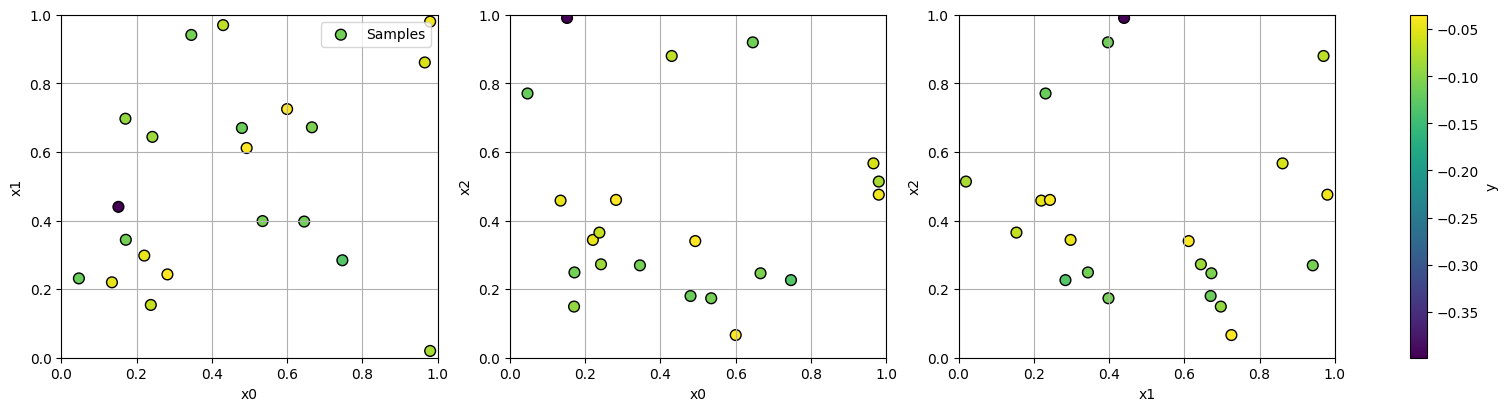

In [27]:
fig, axs = plot_2d_array(X, y)

In [28]:
# Fit Gaussian Process surrogate model on known data
model = get_reg_model(
    n_dimensions=3, seed_input=seed_input, length_scale_bounds=(1e-2, 10)
)
model.fit(X, y)

# Use Probability of Improvement (PI) acquisition function and generate
# candidates from top 10%.
x_candidates = suggest_local_candidates(
    x_samples=X,
    y_samples=y,
    model=model,
    acq_func=acquisition.prob_improv,
    y_max=y.max(),
    fraction=0.1,
)

for x_ in x_candidates:
    current_point, candidates, acq_scores = x_
    print(f"PI acquisition function outputs for candidates around point {current_point}:")
    for candidate, score in zip(candidates, acq_scores):
        print(f"{score}: {candidate}")
    print("")

PI acquisition function outputs for candidates around point [0.282  0.243  0.4602]:
0.4168249516673651: [0.332     0.293     0.4344039]
0.38294950526508376: [0.332     0.193     0.4344039]
0.3732705193096852: [0.332     0.293     0.4859961]
0.336342038772187: [0.332     0.193     0.4859961]
0.31895891714755276: [0.232     0.293     0.4859961]
0.286503882791994: [0.232     0.193     0.4859961]
0.2751461645865675: [0.232     0.293     0.4344039]
0.2395038107794995: [0.232     0.193     0.4344039]

PI acquisition function outputs for candidates around point [0.49258141 0.61159319 0.34017639]:
0.590951427723486: [0.54258141 0.56159319 0.31438029]
0.5207767505745323: [0.44258141 0.56159319 0.31438029]
0.46245055753029024: [0.54258141 0.66159319 0.31438029]
0.3493634670992541: [0.44258141 0.66159319 0.31438029]
0.31743365650727356: [0.54258141 0.66159319 0.36597249]
0.2791592612295647: [0.54258141 0.56159319 0.36597249]
0.26500692643446855: [0.44258141 0.66159319 0.36597249]
0.20989059604680

In [29]:
top_3_points_idx = np.argsort(y)[:-4:-1]
print("Top 3 points with the highest output:")
for idx in top_3_points_idx:
    print(f"x = {X[idx]}, y = {y[idx]}")

Top 3 points with the highest output:
x = [0.282  0.243  0.4602], y = -0.03465873293384881
x = [0.49258141 0.61159319 0.34017639], y = -0.034835313350078584
x = [0.60009728 0.72513573 0.06608864], y = -0.036377828071632486


In [30]:
observed_point_rank = 2  # second best observed point
candidate_rank = 1  # best candidate
x_next = x_candidates[observed_point_rank - 1][1][candidate_rank - 1]
print(f"Proposed point from candidates = {x_next}")

Proposed point from candidates = [0.54258141 0.56159319 0.31438029]


## Week 8

In [31]:
import numpy as np

from bbo import acquisition
from bbo.bayesian_optimisation import get_reg_model
from bbo.data import get_current_weeks_points
from bbo.plotting import plot_2d_array
from bbo.random import create_rng_seed
from bbo.utils import suggest_local_candidates

seed_input = "function 3"  # input string to create random seed
n_dimensions = 3  # number of features
grd_res = 101  # axis resolution

In [32]:
X, y = get_current_weeks_points(function_id=3, week=8)

print(f"Last week's query {X[-1]} yields {y[-1]}")

Last week's query [0.542581 0.561593 0.31438 ] yields -0.05145203079716532


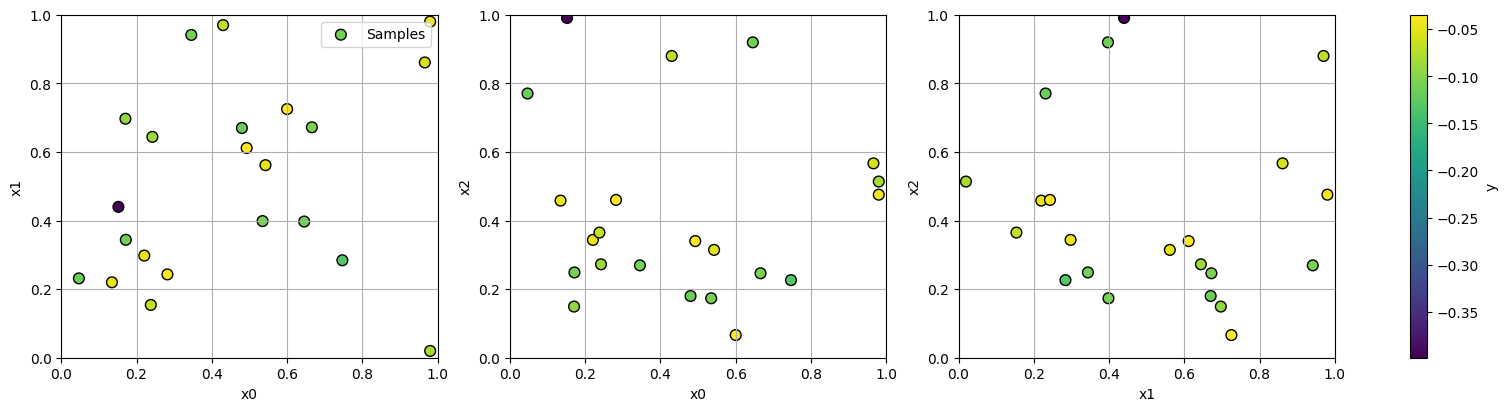

In [33]:
fig, axs = plot_2d_array(X, y)

In [34]:
# Fit Gaussian Process surrogate model on known data
model = get_reg_model(
    n_dimensions=3, seed_input=seed_input, length_scale_bounds=(1e-2, 10)
)
model.fit(X, y)

# Use Probability of Improvement (PI) acquisition function and generate
# candidates from top 10%.
x_candidates = suggest_local_candidates(
    x_samples=X,
    y_samples=y,
    model=model,
    acq_func=acquisition.prob_improv,
    y_max=y.max(),
    fraction=0.1,
)

for x_ in x_candidates:
    current_point, candidates, acq_scores = x_
    print(f"PI acquisition function outputs for candidates around point {current_point}:")
    for candidate, score in zip(candidates, acq_scores):
        print(f"{score}: {candidate}")
    print("")

PI acquisition function outputs for candidates around point [0.282  0.243  0.4602]:
0.44058429027953205: [0.332      0.293      0.43412236]
0.3710584033229921: [0.332      0.293      0.48627764]
0.34584751716323847: [0.332      0.193      0.43412236]
0.3098717569164109: [0.232      0.293      0.48627764]
0.3014017186746366: [0.232      0.293      0.43412236]
0.2925276009774559: [0.332      0.193      0.48627764]
0.24162956655433515: [0.232      0.193      0.48627764]
0.209534463825711: [0.232      0.193      0.43412236]

PI acquisition function outputs for candidates around point [0.49258141 0.61159319 0.34017639]:
0.6749688592520253: [0.54258141 0.66159319 0.36625403]
0.6503218261949624: [0.44258141 0.66159319 0.36625403]
0.598388852041283: [0.54258141 0.56159319 0.36625403]
0.5690891424610606: [0.44258141 0.56159319 0.36625403]
0.0020840570124595796: [0.44258141 0.66159319 0.31409874]
5.48425192216537e-06: [0.54258141 0.66159319 0.31409874]
8.865888746549097e-08: [0.44258141 0.561593

In [35]:
observed_point_rank = 2  # second best observed point
candidate_rank = 1  # best candidate
x_next = x_candidates[observed_point_rank - 1][1][candidate_rank - 1]
print(f"Proposed point from candidates = {x_next}")

Proposed point from candidates = [0.54258141 0.66159319 0.36625403]


## Week 9

In [36]:
import numpy as np

from bbo import acquisition
from bbo.bayesian_optimisation import get_reg_model
from bbo.data import get_current_weeks_points
from bbo.plotting import plot_2d_array
from bbo.random import create_rng_seed
from bbo.utils import suggest_local_candidates

seed_input = "function 3"  # input string to create random seed
n_dimensions = 3  # number of features
grd_res = 101  # axis resolution

In [37]:
X, y = get_current_weeks_points(function_id=3, week=9)

print(f"Last week's query {X[-1]} yields {y[-1]}")

Last week's query [0.542581 0.661593 0.366254] yields -0.03545750237553378


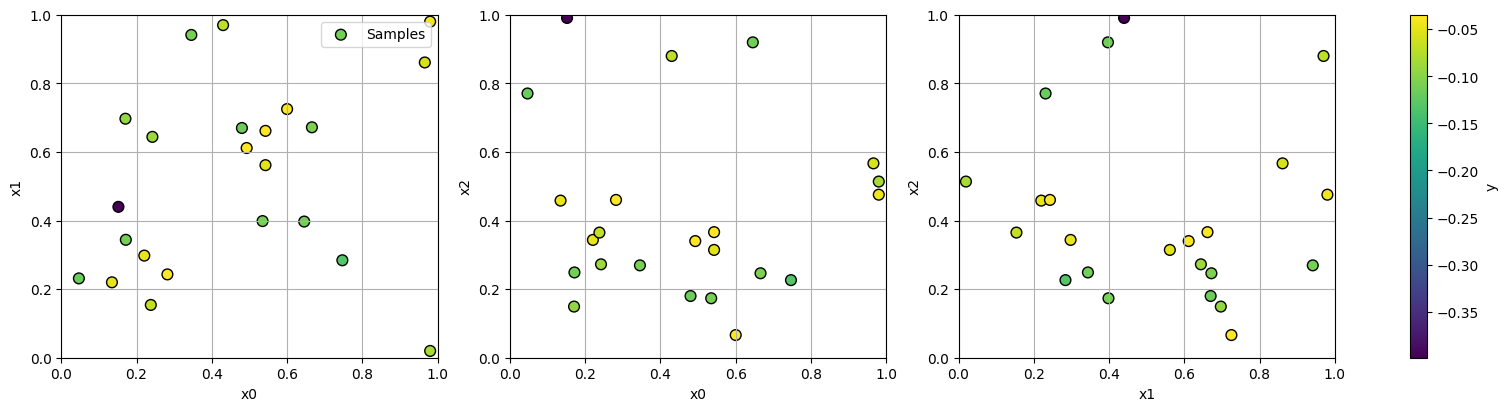

In [38]:
fig, axs = plot_2d_array(X, y)

In [39]:
# Fit Gaussian Process surrogate model on known data
model = get_reg_model(
    n_dimensions=3, seed_input=seed_input, length_scale_bounds=(1e-2, 10)
)
model.fit(X, y)

# Use Probability of Improvement (PI) acquisition function and generate
# candidates from top 10%.
x_candidates = suggest_local_candidates(
    x_samples=X,
    y_samples=y,
    model=model,
    acq_func=acquisition.prob_improv,
    y_max=y.max(),
    fraction=0.1,
)

for x_ in x_candidates:
    current_point, candidates, acq_scores = x_
    print(f"PI acquisition function outputs for candidates around point {current_point}:")
    for candidate, score in zip(candidates, acq_scores):
        print(f"{score}: {candidate}")
    print("")

PI acquisition function outputs for candidates around point [0.282  0.243  0.4602]:
0.7230671139602454: [0.332     0.293     0.5019104]
0.6480723878450003: [0.332     0.193     0.5019104]
0.6397654368786152: [0.232     0.293     0.5019104]
0.5708473771334046: [0.232     0.193     0.5019104]
0.18334681834468713: [0.332     0.293     0.4184896]
0.14230959593121678: [0.232     0.293     0.4184896]
0.024287551066850512: [0.332     0.193     0.4184896]
0.010016852364677465: [0.232     0.193     0.4184896]

PI acquisition function outputs for candidates around point [0.49258141 0.61159319 0.34017639]:
0.7799618200954702: [0.44258141 0.66159319 0.38188679]
0.6911077034903482: [0.44258141 0.56159319 0.38188679]
0.383962396859332: [0.54258141 0.66159319 0.38188679]
0.3157818959844353: [0.54258141 0.56159319 0.38188679]
3.713309400199355e-08: [0.44258141 0.66159319 0.29846598]
1.2959176141681623e-08: [0.44258141 0.56159319 0.29846598]
1.7393846385275345e-12: [0.54258141 0.66159319 0.29846598]
1.

In [40]:
observed_point_rank = 2  # second best observed point
candidate_rank = 1  # best candidate
x_next = x_candidates[observed_point_rank - 1][1][candidate_rank - 1]
print(f"Proposed point from candidates = {x_next}")

Proposed point from candidates = [0.44258141 0.66159319 0.38188679]


## Week 10 - Breakthrough!

In [41]:
import numpy as np

from bbo import acquisition
from bbo.bayesian_optimisation import get_reg_model
from bbo.data import get_current_weeks_points
from bbo.plotting import plot_2d_array
from bbo.random import create_rng_seed
from bbo.utils import suggest_local_candidates

seed_input = "function 3"  # input string to create random seed
n_dimensions = 3  # number of features
grd_res = 101  # axis resolution

In [42]:
X, y = get_current_weeks_points(function_id=3, week=10)

print(f"Last week's query {X[-1]} yields {y[-1]}")

Last week's query [0.442581 0.661593 0.381887] yields -0.017490862689732798


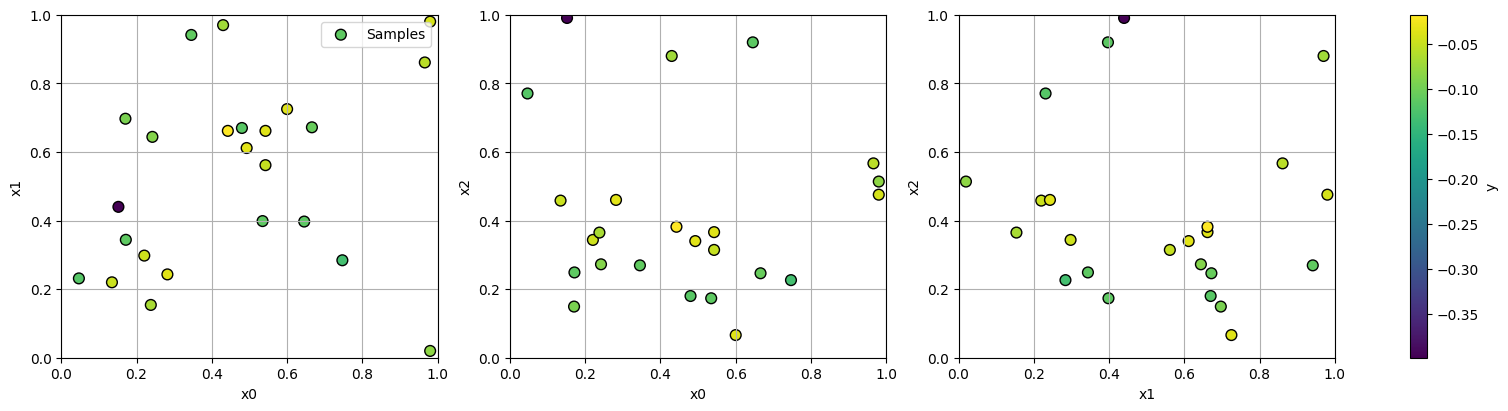

In [43]:
fig, axs = plot_2d_array(X, y)

In [44]:
# Fit Gaussian Process surrogate model on known data
model = get_reg_model(
    n_dimensions=3, seed_input=seed_input, length_scale_bounds=(1e-2, 10)
)
model.fit(X, y)

# Use Probability of Improvement (PI) acquisition function and generate
# candidates from top 10%.
x_candidates = suggest_local_candidates(
    x_samples=X,
    y_samples=y,
    model=model,
    acq_func=acquisition.prob_improv,
    y_max=y.max(),
    fraction=0.1,
)

for x_ in x_candidates:
    current_point, candidates, acq_scores = x_
    print(f"PI acquisition function outputs for candidates around point {current_point}:")
    for candidate, score in zip(candidates, acq_scores):
        print(f"{score}: {candidate}")
    print("")

PI acquisition function outputs for candidates around point [0.442581 0.661593 0.381887]:
0.9535247354488984: [0.392581   0.611593   0.42655623]
0.9517082146774857: [0.392581   0.711593   0.42655623]
0.728785327264577: [0.492581   0.711593   0.42655623]
0.6337611353262078: [0.492581   0.611593   0.42655623]
0.02217663766943387: [0.392581   0.711593   0.33721777]
1.4526064406189049e-05: [0.492581   0.711593   0.33721777]
4.2409035218557067e-08: [0.392581   0.611593   0.33721777]
0.0: [0.492581   0.611593   0.33721777]

PI acquisition function outputs for candidates around point [0.282  0.243  0.4602]:
0.3509989119812703: [0.332      0.293      0.50486923]
0.28521041476789066: [0.232      0.293      0.50486923]
0.21483020397842983: [0.332      0.193      0.50486923]
0.16888609993126952: [0.232      0.193      0.50486923]
0.01958093924462131: [0.332      0.293      0.41553077]
0.016126118919242528: [0.232      0.293      0.41553077]
0.0001054444345291476: [0.332      0.193      0.41553077

In [45]:
top_3_points_idx = np.argsort(y)[:-4:-1]
print("Top 3 points with the highest output:")
for idx in top_3_points_idx:
    print(f"x = {X[idx]}, y = {y[idx]}")

Top 3 points with the highest output:
x = [0.442581 0.661593 0.381887], y = -0.017490862689732798
x = [0.282  0.243  0.4602], y = -0.03465873293384881
x = [0.49258141 0.61159319 0.34017639], y = -0.034835313350078584


In [46]:
observed_point_rank = 1  # best observed point
candidate_rank = 1  # best candidate
x_next = x_candidates[observed_point_rank - 1][1][candidate_rank - 1]
print(f"Proposed point from candidates = {x_next}")

Proposed point from candidates = [0.392581   0.611593   0.42655623]


## Week 11

In [47]:
import numpy as np

from bbo import acquisition
from bbo.bayesian_optimisation import get_reg_model
from bbo.data import get_current_weeks_points
from bbo.plotting import plot_2d_array
from bbo.random import create_rng_seed
from bbo.utils import suggest_local_candidates

seed_input = "function 3"  # input string to create random seed
n_dimensions = 3  # number of features
grd_res = 101  # axis resolution

In [48]:
X, y = get_current_weeks_points(function_id=3, week=11)

print(f"Last week's query {X[-1]} yields {y[-1]}")

Last week's query [0.392581 0.611593 0.426556] yields -0.01710866852902856


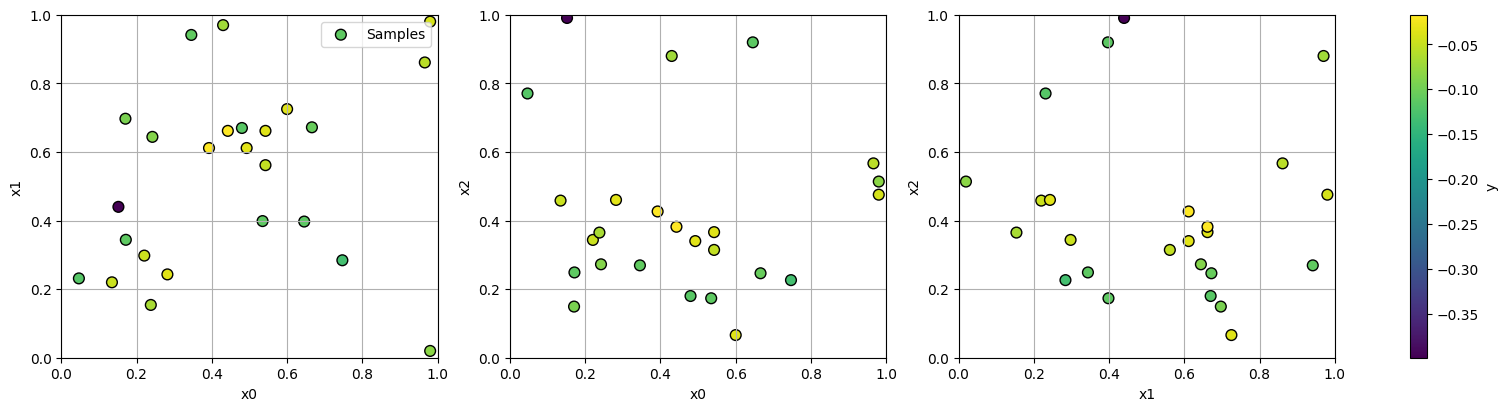

In [49]:
fig, axs = plot_2d_array(X, y)

In [50]:
# Fit Gaussian Process surrogate model on known data
model = get_reg_model(
    n_dimensions=3, seed_input=seed_input, length_scale_bounds=(1e-2, 10)
)
model.fit(X, y)

# Use Probability of Improvement (PI) acquisition function and generate
# candidates from top 10%.
x_candidates = suggest_local_candidates(
    x_samples=X,
    y_samples=y,
    model=model,
    acq_func=acquisition.prob_improv,
    y_max=y.max(),
    fraction=0.1,
)

for x_ in x_candidates:
    current_point, candidates, acq_scores = x_
    print(f"PI acquisition function outputs for candidates around point {current_point}:")
    for candidate, score in zip(candidates, acq_scores):
        print(f"{score}: {candidate}")
    print("")

PI acquisition function outputs for candidates around point [0.392581 0.611593 0.426556]:
0.9931432467508393: [0.342581   0.661593   0.38509938]
0.7874712257766165: [0.342581   0.561593   0.38509938]
0.270783283499346: [0.342581   0.661593   0.46801262]
0.26075354198311085: [0.442581   0.661593   0.46801262]
0.24712484757888958: [0.442581   0.661593   0.38509938]
0.2287488012327194: [0.342581   0.561593   0.46801262]
0.22001257693967047: [0.442581   0.561593   0.46801262]
0.13096602990622197: [0.442581   0.561593   0.38509938]

PI acquisition function outputs for candidates around point [0.442581 0.661593 0.381887]:
0.8358135219535837: [0.392581   0.611593   0.42334362]
0.775428256594437: [0.392581   0.711593   0.42334362]
0.22555276271868513: [0.492581   0.711593   0.42334362]
0.1527760995623823: [0.392581   0.711593   0.34043038]
0.06775812072656105: [0.492581   0.611593   0.42334362]
0.0002845980220541609: [0.492581   0.711593   0.34043038]
2.929117156090226e-05: [0.392581   0.61159

In [51]:
observed_point_rank = 1  # best observed point
candidate_rank = 1  # best candidate
x_next = x_candidates[observed_point_rank - 1][1][candidate_rank - 1]
print(f"Proposed point from candidates = {x_next}")

Proposed point from candidates = [0.342581   0.661593   0.38509938]


## Week 12

In [52]:
import numpy as np

from bbo import acquisition
from bbo.bayesian_optimisation import get_reg_model
from bbo.data import get_current_weeks_points
from bbo.plotting import plot_2d_array
from bbo.random import create_rng_seed
from bbo.utils import suggest_local_candidates

seed_input = "function 3"  # input string to create random seed
n_dimensions = 3  # number of features
grd_res = 101  # axis resolution

In [53]:
X, y = get_current_weeks_points(function_id=3, week=12)

print(f"Last week's query {X[-1]} yields {y[-1]}")

Last week's query [0.342581 0.661593 0.385099] yields -0.018601195442758522


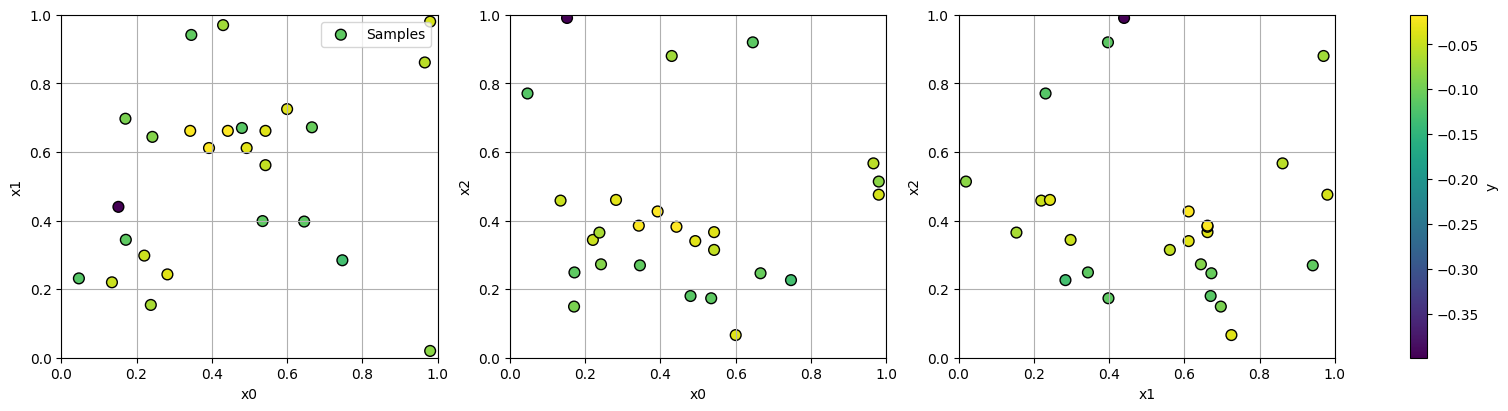

In [54]:
fig, axs = plot_2d_array(X, y)

In [55]:
# Fit Gaussian Process surrogate model on known data
model = get_reg_model(
    n_dimensions=3, seed_input=seed_input, length_scale_bounds=(1e-2, 10)
)
model.fit(X, y)

# Use Probability of Improvement (PI) acquisition function and generate
# candidates from top 10%.
x_candidates = suggest_local_candidates(
    x_samples=X,
    y_samples=y,
    model=model,
    acq_func=acquisition.prob_improv,
    y_max=y.max(),
    fraction=0.1,
)

for x_ in x_candidates:
    current_point, candidates, acq_scores = x_
    print(f"PI acquisition function outputs for candidates around point {current_point}:")
    for candidate, score in zip(candidates, acq_scores):
        print(f"{score}: {candidate}")
    print("")

PI acquisition function outputs for candidates around point [0.392581 0.611593 0.426556]:
0.9867146262743053: [0.442581   0.661593   0.39069383]
0.4539019500035121: [0.442581   0.661593   0.46241817]
0.4065146522900497: [0.442581   0.561593   0.46241817]
0.3313561941400573: [0.342581   0.661593   0.46241817]
0.27413210215274325: [0.342581   0.561593   0.46241817]
0.20487075733526738: [0.442581   0.561593   0.39069383]
0.029640707000627188: [0.342581   0.561593   0.39069383]
0.010095240928862517: [0.342581   0.661593   0.39069383]

PI acquisition function outputs for candidates around point [0.442581 0.661593 0.381887]:
0.8469383092193281: [0.392581   0.711593   0.41774917]
0.8140138565347531: [0.492581   0.711593   0.41774917]
0.5768740335152346: [0.492581   0.611593   0.41774917]
0.5209669049930115: [0.392581   0.611593   0.41774917]
0.14253662945592843: [0.392581   0.711593   0.34602483]
0.004408018568740753: [0.392581   0.611593   0.34602483]
0.00011351998172937915: [0.492581   0.71

In [56]:
observed_point_rank = 1  # best observed point
candidate_rank = 1  # best candidate
x_next = x_candidates[observed_point_rank - 1][1][candidate_rank - 1]
print(f"Proposed point from candidates = {x_next}")

Proposed point from candidates = [0.442581   0.661593   0.39069383]


## Week 13

In [57]:
import numpy as np

from bbo import acquisition
from bbo.bayesian_optimisation import get_reg_model
from bbo.data import get_current_weeks_points
from bbo.plotting import plot_2d_array
from bbo.random import create_rng_seed
from bbo.utils import suggest_local_candidates

seed_input = "function 3"  # input string to create random seed
n_dimensions = 3  # number of features
grd_res = 101  # axis resolution

In [58]:
X, y = get_current_weeks_points(function_id=3, week=13)

print(f"Last week's query {X[-1]} yields {y[-1]}")

Last week's query [0.442581 0.661593 0.390694] yields -0.01899806447758267


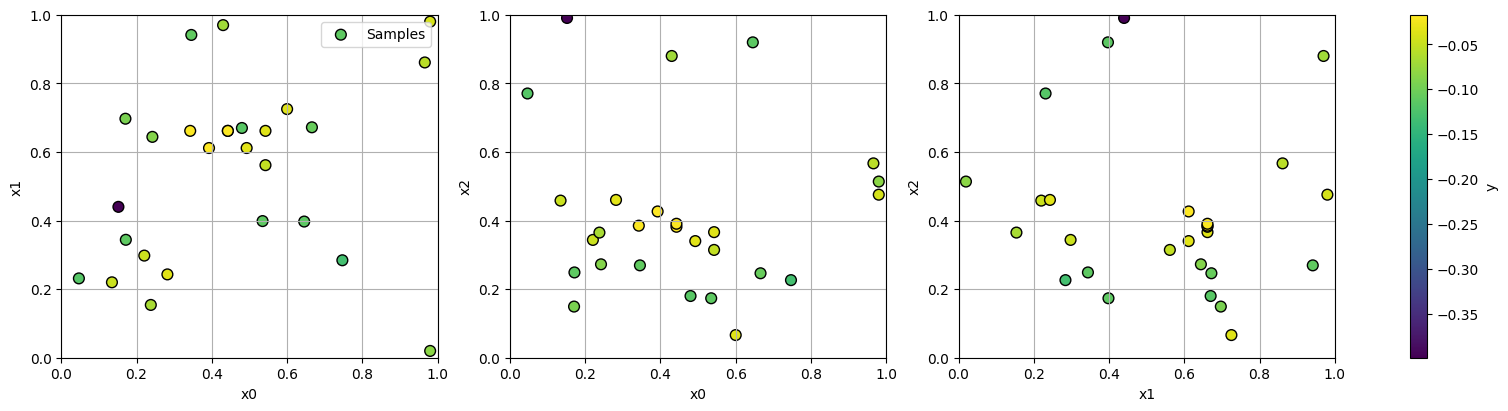

In [59]:
fig, axs = plot_2d_array(X, y)

In [60]:
# Fit Gaussian Process surrogate model on known data
model = get_reg_model(
    n_dimensions=3, seed_input=seed_input, length_scale_bounds=(1e-2, 10)
)
model.fit(X, y)

# Use Probability of Improvement (PI) acquisition function and generate
# candidates from top 10%.
x_candidates = suggest_local_candidates(
    x_samples=X,
    y_samples=y,
    model=model,
    acq_func=acquisition.prob_improv,
    y_max=y.max(),
    fraction=0.1,
)

for x_ in x_candidates:
    current_point, candidates, acq_scores = x_
    print(f"PI acquisition function outputs for candidates around point {current_point}:")
    for candidate, score in zip(candidates, acq_scores):
        print(f"{score}: {candidate}")
    print("")

PI acquisition function outputs for candidates around point [0.392581 0.611593 0.426556]:
0.7856700791959907: [0.342581   0.661593   0.45274576]
0.7740662415139279: [0.442581   0.661593   0.45274576]
0.7329848781908029: [0.342581   0.561593   0.45274576]
0.6989307069153011: [0.442581   0.561593   0.45274576]
0.04413162925616236: [0.342581   0.661593   0.40036624]
0.01842953917208386: [0.442581   0.561593   0.40036624]
0.006405691968152465: [0.342581   0.561593   0.40036624]
8.99786461201597e-08: [0.442581   0.661593   0.40036624]

PI acquisition function outputs for candidates around point [0.442581 0.661593 0.381887]:
0.8086640393678034: [0.392581   0.711593   0.35569724]
0.5538678188088674: [0.392581   0.711593   0.40807676]
0.4872953693513577: [0.392581   0.611593   0.35569724]
0.18884295821449698: [0.492581   0.711593   0.40807676]
0.03474514367400669: [0.492581   0.611593   0.40807676]
0.016764066095466455: [0.392581   0.611593   0.40807676]
0.008485881489197954: [0.492581   0.711

In [61]:
observed_point_rank = 3  # third best observed point
candidate_rank = 1  # best candidate
x_next = x_candidates[observed_point_rank - 1][1][candidate_rank - 1]
print(f"Proposed point from candidates = {x_next}")

Proposed point from candidates = [0.392581   0.711593   0.35890924]


## Final Result

In [62]:
from bbo.data import get_current_weeks_points

X, y = get_current_weeks_points(function_id=3, week=14)

print(f"Last week's query {X[-1]} yields {y[-1]}")

Last week's query [0.392581 0.711593 0.358909] yields -0.030943620635451433
